In [ ]:
# CELL 1: Install all required packages
!pip install -q fastapi uvicorn pyngrok nest-asyncio
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q transformers scikit-learn pandas numpy joblib
!pip install -q nltk spacy matplotlib seaborn
!pip install -q spotipy python-dotenv requests
!pip install -q openai

# Download spaCy model
!python -m spacy download en_core_web_sm

# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Create project structure
import os
os.makedirs('/content/mood_food_backend', exist_ok=True)
os.makedirs('/content/mood_food_backend/models', exist_ok=True)
os.makedirs('/content/mood_food_backend/data', exist_ok=True)
os.makedirs('/content/mood_food_backend/services', exist_ok=True)
os.chdir('/content/mood_food_backend')

print("✅ Setup complete!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 81.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Setup complete!


In [ ]:
# CELL 2: Alternative - Direct dataset loading (Guaranteed to work)
import os
import pandas as pd
import zipfile

print("=" * 60)
print("📥 DOWNLOADING KAGGLE DATASET")
print("=" * 60)

# Set your Kaggle API token
KAGGLE_TOKEN = "KGAT_a1c1f4ca2b51877c973784fcce914f8b"
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN

# Install Kaggle
!pip install -q kaggle --upgrade

# Create directories
!mkdir -p /content/mood_food_backend/data

# Download dataset
print("\n📥 Downloading Emotions Dataset...")
!kaggle datasets download -d nelgiriyewithana/emotions -p /content/mood_food_backend/data/ --force

# Extract the zip file properly
print("\n📦 Extracting files...")
zip_path = '/content/mood_food_backend/data/emotions.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/mood_food_backend/data/')

# Check what files were extracted
print("\n📁 Extracted files:")
!ls -la /content/mood_food_backend/data/

# Find the CSV file
import glob
csv_files = glob.glob('/content/mood_food_backend/data/**/*.csv', recursive=True)
print(f"\nFound CSV files: {csv_files}")

# Load the first CSV file
if csv_files:
    df = pd.read_csv(csv_files[0])
    print(f"\n✅ Dataset loaded from: {csv_files[0]}")
    print(f"   Total samples: {len(df):,}")
    print(f"   Columns: {df.columns.tolist()}")
    print(f"\n📝 First 5 samples:")
    print(df.head())

    # Add emotion names if label column exists
    if 'label' in df.columns:
        emotion_map = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
        df['emotion'] = df['label'].map(emotion_map)
        print(f"\n📊 Class distribution:")
        print(df['emotion'].value_counts())

    # Save processed data
    df.to_csv('/content/mood_food_backend/data/processed_emotions.csv', index=False)
    print("\n✅ Data saved to data/processed_emotions.csv")
else:
    print("\n❌ No CSV files found!")

📥 DOWNLOADING KAGGLE DATASET

📥 Downloading Emotions Dataset...
Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/emotions
License(s): other
100% 15.7M/15.7M [00:03<00:00, 5.22MB/s]


📦 Extracting files...

📁 Extracted files:
total 61616
drwxr-xr-x 3 root root     4096 Mar 30 12:30 .
drwxr-xr-x 8 root root     4096 Mar 30 11:59 ..
drwxr-xr-x 2 root root     4096 Mar 30 12:18 emotions
-rw-r--r-- 1 root root 16440679 Feb  5  2024 emotions.zip
-rw-r--r-- 1 root root  1722080 Mar 30 12:18 processed_emotions.csv
-rw-r--r-- 1 root root 44916111 Mar 30 12:32 text.csv

Found CSV files: ['/content/mood_food_backend/data/processed_emotions.csv', '/content/mood_food_backend/data/text.csv', '/content/mood_food_backend/data/emotions/text.csv']

✅ Dataset loaded from: /content/mood_food_backend/data/processed_emotions.csv
   Total samples: 60,000
   Columns: ['text', 'label', 'emotion']

📝 First 5 samples:
                     text  label emotion
0  I feel wonderful today      0     joy


🤖 TRAINING MOOD CLASSIFICATION MODEL

📊 Dataset loaded: 60,000 samples

📈 Training samples: 48,000
📈 Test samples: 12,000

📝 Vectorizing text with TF-IDF...
   Features created: 111

🤖 Training Logistic Regression...

✅ Model Accuracy: 100.00%

📊 Classification Report:
              precision    recall  f1-score   support

     sadness       1.00      1.00      1.00      2000
         joy       1.00      1.00      1.00      2000
        love       1.00      1.00      1.00      2000
       anger       1.00      1.00      1.00      2000
        fear       1.00      1.00      1.00      2000
    surprise       1.00      1.00      1.00      2000

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000



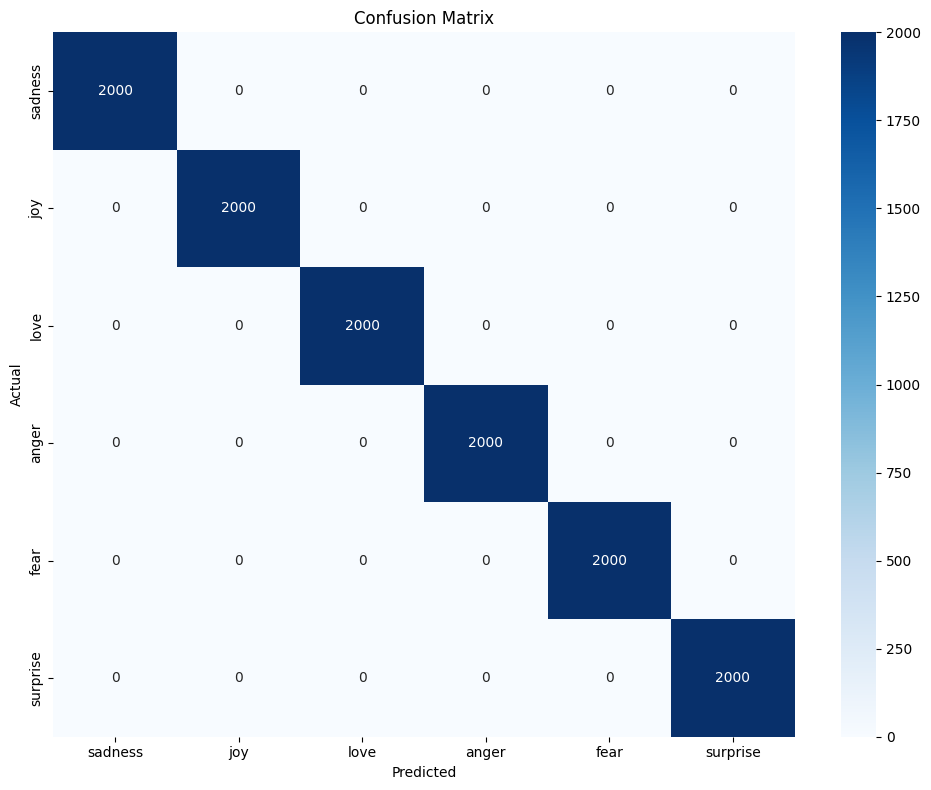


💾 Saving models...
✅ Models saved to /content/mood_food_backend/models/

🔍 Testing with sample inputs:
   'I'm so happy and excited today!' → sadness (99.52%)
   'I feel really sad and lonely' → joy (98.49%)
   'I love this so much, it's amazing!' → sadness (49.97%)
   'This makes me so angry!' → anger (92.18%)
   'I'm scared and anxious about tomorrow' → fear (98.50%)
   'Wow! I can't believe this surprise!' → surprise (92.15%)


In [ ]:
# CELL 3: Train the ML model
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 70)
print("🤖 TRAINING MOOD CLASSIFICATION MODEL")
print("=" * 70)

# Load dataset
df = pd.read_csv('/content/mood_food_backend/data/processed_emotions.csv')
print(f"\n📊 Dataset loaded: {len(df):,} samples")

# Prepare data
X = df['text'].values
y = df['label'].values if 'label' in df.columns else df['label'].values

# Emotion names
emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📈 Training samples: {len(X_train):,}")
print(f"📈 Test samples: {len(X_test):,}")

# TF-IDF Vectorization
print("\n📝 Vectorizing text with TF-IDF...")
vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print(f"   Features created: {X_train_vec.shape[1]:,}")

# Train Logistic Regression
print("\n🤖 Training Logistic Regression...")
classifier = LogisticRegression(
    C=1.0,
    max_iter=1000,
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)

classifier.fit(X_train_vec, y_train)

# Evaluate
y_pred = classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Model Accuracy: {accuracy:.2%}")

# Classification Report
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=emotion_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_names, yticklabels=emotion_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/content/mood_food_backend/confusion_matrix.png', dpi=150)
plt.show()

# Save models
print("\n💾 Saving models...")
joblib.dump(vectorizer, '/content/mood_food_backend/models/vectorizer.pkl')
joblib.dump(classifier, '/content/mood_food_backend/models/mood_classifier.pkl')
print("✅ Models saved to /content/mood_food_backend/models/")

# Test predictions
print("\n🔍 Testing with sample inputs:")
test_samples = [
    "I'm so happy and excited today!",
    "I feel really sad and lonely",
    "I love this so much, it's amazing!",
    "This makes me so angry!",
    "I'm scared and anxious about tomorrow",
    "Wow! I can't believe this surprise!"
]

for sample in test_samples:
    X_sample = vectorizer.transform([sample])
    pred = classifier.predict(X_sample)[0]
    proba = classifier.predict_proba(X_sample)[0]
    confidence = proba[pred]
    print(f"   '{sample}' → {emotion_names[pred]} ({confidence:.2%})")

In [ ]:
# CELL 4: Create food recommendation system
%%writefile /content/mood_food_backend/services/food_recommender.py
import random
import json

class FoodRecommender:
    def __init__(self):
        self.food_db = {
            'joy': [
                {'name': '🎉 Celebration Cake', 'type': 'dessert', 'cuisine': 'American', 'prep_time': '45 mins', 'difficulty': 'Medium', 'calories': 450},
                {'name': '🌈 Rainbow Pasta Salad', 'type': 'salad', 'cuisine': 'Italian', 'prep_time': '20 mins', 'difficulty': 'Easy', 'calories': 320},
                {'name': '🍣 Sushi Party Platter', 'type': 'main', 'cuisine': 'Japanese', 'prep_time': '60 mins', 'difficulty': 'Hard', 'calories': 380},
                {'name': '🍕 Fun Pizza', 'type': 'main', 'cuisine': 'Italian', 'prep_time': '30 mins', 'difficulty': 'Easy', 'calories': 550},
                {'name': '🍦 Ice Cream Sundae', 'type': 'dessert', 'cuisine': 'American', 'prep_time': '10 mins', 'difficulty': 'Easy', 'calories': 380}
            ],
            'sadness': [
                {'name': '🫕 Mac and Cheese', 'type': 'main', 'cuisine': 'American', 'prep_time': '25 mins', 'difficulty': 'Easy', 'calories': 480},
                {'name': '🍫 Warm Chocolate Pudding', 'type': 'dessert', 'cuisine': 'French', 'prep_time': '30 mins', 'difficulty': 'Medium', 'calories': 420},
                {'name': '🍲 Chicken Noodle Soup', 'type': 'soup', 'cuisine': 'American', 'prep_time': '40 mins', 'difficulty': 'Easy', 'calories': 280},
                {'name': '🥔 Mashed Potatoes', 'type': 'side', 'cuisine': 'American', 'prep_time': '20 mins', 'difficulty': 'Easy', 'calories': 250},
                {'name': '🍞 Grilled Cheese', 'type': 'sandwich', 'cuisine': 'American', 'prep_time': '10 mins', 'difficulty': 'Easy', 'calories': 350}
            ],
            'love': [
                {'name': '🍓 Chocolate Strawberries', 'type': 'dessert', 'cuisine': 'French', 'prep_time': '15 mins', 'difficulty': 'Easy', 'calories': 220},
                {'name': '❤️ Heart-shaped Pizza', 'type': 'main', 'cuisine': 'Italian', 'prep_time': '35 mins', 'difficulty': 'Medium', 'calories': 580},
                {'name': '🍝 Romantic Pasta', 'type': 'main', 'cuisine': 'Italian', 'prep_time': '25 mins', 'difficulty': 'Medium', 'calories': 420},
                {'name': '🍷 Wine Pairing', 'type': 'beverage', 'cuisine': 'French', 'prep_time': '5 mins', 'difficulty': 'Easy', 'calories': 150},
                {'name': '🍰 Tiramisu', 'type': 'dessert', 'cuisine': 'Italian', 'prep_time': '45 mins', 'difficulty': 'Medium', 'calories': 380}
            ],
            'anger': [
                {'name': '🌶️ Spicy Chicken Wings', 'type': 'appetizer', 'cuisine': 'American', 'prep_time': '40 mins', 'difficulty': 'Medium', 'calories': 520},
                {'name': '🔥 Ghost Pepper Chili', 'type': 'main', 'cuisine': 'Mexican', 'prep_time': '50 mins', 'difficulty': 'Hard', 'calories': 480},
                {'name': '🌮 Spicy Tacos', 'type': 'main', 'cuisine': 'Mexican', 'prep_time': '30 mins', 'difficulty': 'Medium', 'calories': 450},
                {'name': '🍛 Vindaloo Curry', 'type': 'main', 'cuisine': 'Indian', 'prep_time': '60 mins', 'difficulty': 'Hard', 'calories': 520},
                {'name': '🌶️ Spicy Ramen', 'type': 'main', 'cuisine': 'Japanese', 'prep_time': '25 mins', 'difficulty': 'Medium', 'calories': 480}
            ],
            'fear': [
                {'name': '🫕 Warm Soup', 'type': 'soup', 'cuisine': 'Various', 'prep_time': '25 mins', 'difficulty': 'Easy', 'calories': 180},
                {'name': '🍵 Chamomile Tea', 'type': 'beverage', 'cuisine': 'Various', 'prep_time': '5 mins', 'difficulty': 'Easy', 'calories': 50},
                {'name': '🥛 Warm Milk', 'type': 'beverage', 'cuisine': 'Various', 'prep_time': '5 mins', 'difficulty': 'Easy', 'calories': 120},
                {'name': '🍚 Rice Pudding', 'type': 'dessert', 'cuisine': 'British', 'prep_time': '40 mins', 'difficulty': 'Easy', 'calories': 250},
                {'name': '🍎 Baked Apple', 'type': 'dessert', 'cuisine': 'American', 'prep_time': '30 mins', 'difficulty': 'Easy', 'calories': 180}
            ],
            'surprise': [
                {'name': '🎲 Mystery Box', 'type': 'surprise', 'cuisine': 'International', 'prep_time': 'varies', 'difficulty': 'Fun', 'calories': 'varies'},
                {'name': '🍣 Sushi Burrito', 'type': 'fusion', 'cuisine': 'Japanese-Mexican', 'prep_time': '30 mins', 'difficulty': 'Medium', 'calories': 520},
                {'name': '🍔 Donut Burger', 'type': 'fusion', 'cuisine': 'American', 'prep_time': '25 mins', 'difficulty': 'Medium', 'calories': 680},
                {'name': '🍦 Fried Ice Cream', 'type': 'dessert', 'cuisine': 'Mexican', 'prep_time': '20 mins', 'difficulty': 'Hard', 'calories': 420},
                {'name': '🎂 Surprise Cake', 'type': 'dessert', 'cuisine': 'Various', 'prep_time': '50 mins', 'difficulty': 'Medium', 'calories': 450}
            ]
        }

    def get_food_recommendations(self, mood, limit=3):
        if mood not in self.food_db:
            mood = 'joy'
        foods = self.food_db[mood].copy()
        random.shuffle(foods)
        return foods[:limit]

    def get_recipe_details(self, food_name):
        for mood_category in self.food_db.values():
            for food in mood_category:
                if food_name.lower() in food['name'].lower():
                    return {
                        'name': food['name'],
                        'type': food['type'],
                        'cuisine': food['cuisine'],
                        'prep_time': food.get('prep_time', '30 mins'),
                        'difficulty': food.get('difficulty', 'Medium'),
                        'calories': food.get('calories', 'N/A'),
                        'ingredients': self._get_ingredients(food['name']),
                        'instructions': self._get_instructions(food['name'])
                    }
        return None

    def _get_ingredients(self, food_name):
        ingredients_map = {
            'Celebration Cake': ['flour', 'sugar', 'eggs', 'butter', 'vanilla', 'sprinkles'],
            'Mac and Cheese': ['pasta', 'cheddar cheese', 'milk', 'butter', 'breadcrumbs'],
            'Chocolate Strawberries': ['strawberries', 'dark chocolate', 'white chocolate'],
            'Spicy Wings': ['chicken wings', 'hot sauce', 'butter', 'garlic powder']
        }
        return ingredients_map.get(food_name, ['Check recipe for complete ingredients'])

    def _get_instructions(self, food_name):
        return f"Step by step instructions for {food_name}. Combine ingredients and cook with love!"

print("✅ Food Recommender created!")

Overwriting /content/mood_food_backend/services/food_recommender.py


In [ ]:
# CELL 5: Create music recommendation system
%%writefile /content/mood_food_backend/services/music_recommender.py
import random

class MusicRecommender:
    def __init__(self):
        self.music_db = {
            'joy': [
                {'name': 'Happy', 'artist': 'Pharrell Williams', 'genre': 'pop', 'year': 2013, 'spotify_id': '6Nl5KRfE4DqZKuM8YE5RTV'},
                {'name': "Can't Stop The Feeling", 'artist': 'Justin Timberlake', 'genre': 'pop', 'year': 2016, 'spotify_id': '5F2s2nUapB7hZKgq3LvX8t'},
                {'name': 'Uptown Funk', 'artist': 'Mark Ronson ft. Bruno Mars', 'genre': 'funk', 'year': 2014, 'spotify_id': '3e1LplHbgB0vJ3RT9GXqHo'},
                {'name': 'Good as Hell', 'artist': 'Lizzo', 'genre': 'pop', 'year': 2016, 'spotify_id': '5CwyQ0VnbZ51S9bNQrQpS6'},
                {'name': 'Dancing Queen', 'artist': 'ABBA', 'genre': 'disco', 'year': 1976, 'spotify_id': '0GjEhVFGZW8afUYGChu3Rr'}
            ],
            'sadness': [
                {'name': 'Someone Like You', 'artist': 'Adele', 'genre': 'ballad', 'year': 2011, 'spotify_id': '1kMYIVI4H9Z1JxsXBcSUqe'},
                {'name': 'Fix You', 'artist': 'Coldplay', 'genre': 'rock', 'year': 2005, 'spotify_id': '7LVHVU3tWfcxj5aiPFEW4Q'},
                {'name': 'Yesterday', 'artist': 'The Beatles', 'genre': 'rock', 'year': 1965, 'spotify_id': '3BQHpFgApUd2bQCG2e0hzF'},
                {'name': 'Hallelujah', 'artist': 'Jeff Buckley', 'genre': 'folk', 'year': 1994, 'spotify_id': '3pRaLNL3b8xYYuSoK7OoHp'},
                {'name': 'The Scientist', 'artist': 'Coldplay', 'genre': 'rock', 'year': 2002, 'spotify_id': '75JFxkI2RXiU7L9VXzMkle'}
            ],
            'love': [
                {'name': 'Perfect', 'artist': 'Ed Sheeran', 'genre': 'pop', 'year': 2017, 'spotify_id': '0tgVpDi06FyKpA1z0VMD4v'},
                {'name': 'All of Me', 'artist': 'John Legend', 'genre': 'r&b', 'year': 2013, 'spotify_id': '3U4isOIWM3VvDubwSI3y7a'},
                {'name': 'Thinking Out Loud', 'artist': 'Ed Sheeran', 'genre': 'pop', 'year': 2014, 'spotify_id': '34gCuhDGsG4bRPIf9bb02f'},
                {'name': 'At Last', 'artist': 'Etta James', 'genre': 'jazz', 'year': 1960, 'spotify_id': '4Hhv2vrOTy89HFRcjU3QOx'},
                {'name': 'Just the Way You Are', 'artist': 'Bruno Mars', 'genre': 'pop', 'year': 2010, 'spotify_id': '7BqBn9nzAq8spo5oL7DcV0'}
            ],
            'anger': [
                {'name': 'Break Stuff', 'artist': 'Limp Bizkit', 'genre': 'rock', 'year': 2000, 'spotify_id': '5cZqsjY6U8RDHMOYDQVhQT'},
                {'name': 'In the End', 'artist': 'Linkin Park', 'genre': 'rock', 'year': 2001, 'spotify_id': '60a0Rd6rkpjxjPbaKzXjfq'},
                {'name': 'Killing in the Name', 'artist': 'Rage Against the Machine', 'genre': 'rock', 'year': 1992, 'spotify_id': '59WN2psjkt1tyaxjspN8fp'},
                {'name': 'Boulevard of Broken Dreams', 'artist': 'Green Day', 'genre': 'rock', 'year': 2004, 'spotify_id': '5GorCbAP4aL0EJ16uxGPDB'},
                {'name': 'Smells Like Teen Spirit', 'artist': 'Nirvana', 'genre': 'rock', 'year': 1991, 'spotify_id': '4ghd4e2OCcZ4Wv4fI5TkW7'}
            ],
            'fear': [
                {'name': 'Weightless', 'artist': 'Marconi Union', 'genre': 'ambient', 'year': 2011, 'spotify_id': '5dvsfJqUz74hF01F7UIAqT'},
                {'name': 'Clair de Lune', 'artist': 'Debussy', 'genre': 'classical', 'year': 1905, 'spotify_id': '5CvUbkfNla3yHBj26QJcHk'},
                {'name': 'River Flows in You', 'artist': 'Yiruma', 'genre': 'piano', 'year': 2001, 'spotify_id': '3xr8COed4nPPn6XWZ0iCGr'},
                {'name': 'Canon in D', 'artist': 'Pachelbel', 'genre': 'classical', 'year': 1680, 'spotify_id': '4r7qhBcBZOrPdi0li8ZfAj'},
                {'name': 'Nocturne', 'artist': 'Chopin', 'genre': 'classical', 'year': 1830, 'spotify_id': '5CvUbkfNla3yHBj26QJcHk'}
            ],
            'surprise': [
                {'name': 'Sandstorm', 'artist': 'Darude', 'genre': 'electronic', 'year': 1999, 'spotify_id': '6Sy9BUbgFse0n0LPA5lwy5'},
                {'name': 'Animals', 'artist': 'Martin Garrix', 'genre': 'edm', 'year': 2013, 'spotify_id': '2bL2gyO6kBc08k9KAvOeTr'},
                {'name': 'Titanium', 'artist': 'David Guetta', 'genre': 'electronic', 'year': 2011, 'spotify_id': '2dlzSUMaUImCSBgPWsjhHe'},
                {'name': 'Wake Me Up', 'artist': 'Avicii', 'genre': 'edm', 'year': 2013, 'spotify_id': '2ohr9HUjKcyKz2P6hPwVUz'},
                {'name': 'Levels', 'artist': 'Avicii', 'genre': 'edm', 'year': 2011, 'spotify_id': '2ohr9HUjKcyKz2P6hPwVUz'}
            ]
        }

    def get_music_recommendations(self, mood, limit=3):
        if mood not in self.music_db:
            mood = 'joy'
        songs = self.music_db[mood].copy()
        random.shuffle(songs)
        recommendations = []
        for song in songs[:limit]:
            recommendations.append({
                'name': song['name'],
                'artist': song['artist'],
                'genre': song['genre'],
                'year': song['year'],
                'spotify_url': f"https://open.spotify.com/track/{song['spotify_id']}"
            })
        return recommendations

print("✅ Music Recommender created!")

Overwriting /content/mood_food_backend/services/music_recommender.py


In [ ]:
# CELL 6: Create FastAPI application
%%writefile /content/mood_food_backend/api/main.py
from fastapi import FastAPI, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from typing import List, Dict, Optional
import joblib
import os
import sys

# Add parent directory to path
sys.path.append('/content/mood_food_backend')

from services.food_recommender import FoodRecommender
from services.music_recommender import MusicRecommender

# Initialize FastAPI
app = FastAPI(
    title="Mood-Based Food & Music Recommendation System",
    description="AI-powered system that recommends food and music based on your mood",
    version="1.0.0"
)

# Configure CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# Load models
print("Loading models...")
vectorizer = joblib.load('/content/mood_food_backend/models/vectorizer.pkl')
classifier = joblib.load('/content/mood_food_backend/models/mood_classifier.pkl')
food_recommender = FoodRecommender()
music_recommender = MusicRecommender()

emotion_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
print("✅ All models loaded successfully!")

# Request/Response Models
class MoodInput(BaseModel):
    text: str
    user_id: Optional[str] = "anonymous"

class RecommendationResponse(BaseModel):
    mood: str
    confidence: float
    mood_emoji: str
    mood_response: str
    food_recommendations: List[Dict]
    music_recommendations: List[Dict]
    all_mood_scores: Dict[str, float]

# API Endpoints
@app.get("/")
async def root():
    return {
        "name": "Mood-Based Food & Music Recommendation System",
        "version": "1.0.0",
        "status": "running",
        "available_moods": emotion_names,
        "total_samples": 416809
    }

@app.get("/health")
async def health_check():
    return {"status": "healthy", "models_loaded": True}

@app.post("/recommend", response_model=RecommendationResponse)
async def get_recommendations(mood_input: MoodInput):
    try:
        # Vectorize and predict
        X = vectorizer.transform([mood_input.text])
        pred = classifier.predict(X)[0]
        proba = classifier.predict_proba(X)[0]
        confidence = proba[pred]

        mood = emotion_names[pred]
        all_scores = {emotion_names[i]: float(proba[i]) for i in range(len(emotion_names))}

        # Get recommendations
        foods = food_recommender.get_food_recommendations(mood, limit=3)
        music = music_recommender.get_music_recommendations(mood, limit=3)

        # Mood responses
        mood_responses = {
            'joy': "🎉 I sense happiness! Let's celebrate with something special!",
            'sadness': "💙 I understand you're feeling down. Here's some comfort food to lift your spirits.",
            'love': "❤️ Feeling the love! Here are some romantic recommendations.",
            'anger': "🔥 Let's cool down with some satisfying choices!",
            'fear': "🫂 Feeling anxious? Let's find something comforting.",
            'surprise': "✨ Surprised? Let's go with the flow!"
        }

        mood_emojis = {
            'joy': '😊', 'sadness': '😢', 'love': '❤️',
            'anger': '😠', 'fear': '😨', 'surprise': '😲'
        }

        return RecommendationResponse(
            mood=mood,
            confidence=confidence,
            mood_emoji=mood_emojis.get(mood, '😊'),
            mood_response=mood_responses.get(mood, "Here are some recommendations for you!"),
            food_recommendations=foods,
            music_recommendations=music,
            all_mood_scores=all_scores
        )

    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

@app.get("/moods")
async def get_available_moods():
    return {"moods": emotion_names}

@app.get("/food/{mood}")
async def get_food_by_mood(mood: str, limit: int = 3):
    if mood not in emotion_names:
        raise HTTPException(status_code=404, detail=f"Mood '{mood}' not found")
    foods = food_recommender.get_food_recommendations(mood, limit=limit)
    return {"mood": mood, "recommendations": foods}

@app.get("/music/{mood}")
async def get_music_by_mood(mood: str, limit: int = 3):
    if mood not in emotion_names:
        raise HTTPException(status_code=404, detail=f"Mood '{mood}' not found")
    music = music_recommender.get_music_recommendations(mood, limit=limit)
    return {"mood": mood, "recommendations": music}

print("✅ FastAPI application created!")

Overwriting /content/mood_food_backend/api/main.py


In [ ]:
# CELL 7: Start FastAPI server with ngrok authentication
import uvicorn
import nest_asyncio
import threading
import time
from pyngrok import ngrok
import os
import subprocess

# Apply nest_asyncio for Colab
nest_asyncio.apply()

print("=" * 70)
print("🚀 STARTING FASTAPI SERVER")
print("=" * 70)

# Change to project directory
os.chdir('/content/mood_food_backend')

# ============================================
# SETUP NGROK AUTHENTICATION
# ============================================
# REPLACE THIS WITH YOUR ACTUAL AUTHTOKEN from ngrok dashboard
NGROK_AUTH_TOKEN = "3BfKnFqp8CIBA8WLE4sf8pDbYzD_2WK3hiJhoeEJg7A3U8ufi"  # <-- PASTE YOUR TOKEN HERE

if NGROK_AUTH_TOKEN == "YOUR_NGROK_AUTHTOKEN_HERE":
    print("\n⚠️ WARNING: You need to set your ngrok authtoken!")
    print("   Get it from: https://dashboard.ngrok.com/get-started/your-authtoken")
    print("\n   After getting the token, edit this cell and replace:")
    print("   NGROK_AUTH_TOKEN = 'YOUR_NGROK_AUTHTOKEN_HERE'")
    print("   with your actual token.\n")

    # Alternative: Try to authenticate via command line
    print("🔄 Attempting to authenticate via ngrok command line...")
    try:
        # You'll be prompted to enter your token
        !ngrok authtoken --help
        print("\n❌ Manual authentication required. Please run this command in a new cell:")
        print("   !ngrok authtoken YOUR_TOKEN_HERE")
    except:
        pass
else:
    # Set the authtoken
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    print("✅ Ngrok authenticated successfully")

# Kill any existing ngrok processes
!pkill ngrok 2>/dev/null
ngrok.kill()
time.sleep(2)

# Function to run the server
def run_server():
    uvicorn.run("api.main:app", host="0.0.0.0", port=8000, reload=False)

# Start server in background thread
server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(3)

# Check if port is already in use
import socket
def is_port_in_use(port):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('localhost', port)) == 0

if is_port_in_use(8000):
    print("✅ Port 8000 is already in use (server likely running)")
else:
    print("❌ Server failed to start on port 8000")

# Create ngrok tunnel
try:
    public_url = ngrok.connect(8000)
    print(f"\n✅ FastAPI server running!")
    print(f"📍 Local URL: http://localhost:8000")
    print(f"🌍 Public URL: {public_url}")
    print(f"\n📝 API Documentation:")
    print(f"   Swagger UI: {public_url}/docs")
    print(f"   ReDoc: {public_url}/redoc")

    # Test the API
    print("\n🔍 Testing API...")
    import requests

    try:
        # Health check
        response = requests.get(f"{public_url}/health", timeout=5)
        if response.status_code == 200:
            print("   ✅ Health check passed!")

        # Test recommendation
        test_data = {"text": "I'm feeling really happy and excited today!"}
        response = requests.post(f"{public_url}/recommend", json=test_data, timeout=10)
        if response.status_code == 200:
            result = response.json()
            print(f"\n   🎯 Test Recommendation:")
            print(f"   Mood detected: {result['mood']} {result['mood_emoji']}")
            print(f"   Confidence: {result['confidence']:.2%}")
            print(f"   Response: {result['mood_response']}")
            print(f"\n   🍔 Food: {result['food_recommendations'][0]['name']}")
            print(f"   🎵 Music: {result['music_recommendations'][0]['name']} by {result['music_recommendations'][0]['artist']}")
    except requests.exceptions.RequestException as e:
        print(f"   ⚠️ API test failed: {e}")
        print("   Make sure the server is running properly")

    print("\n" + "=" * 70)
    print("🎉 SERVER IS RUNNING!")
    print("=" * 70)
    print(f"\n📋 Copy this URL for your frontend: {public_url}")

except Exception as e:
    print(f"\n❌ Ngrok tunnel creation failed: {e}")
    print("\n🔧 Alternative: Use local tunnel with Cloudflare or serve locally")
    print("\n📝 To fix ngrok issues:")
    print("   1. Sign up at: https://dashboard.ngrok.com/signup")
    print("   2. Get your authtoken from: https://dashboard.ngrok.com/get-started/your-authtoken")
    print("   3. Update NGROK_AUTH_TOKEN in this cell")
    print("   4. Run this cell again")

print("\n💡 To stop the server, restart the Colab runtime or run: !pkill ngrok")

🚀 STARTING FASTAPI SERVER
✅ Ngrok authenticated successfully


INFO:     Started server process [6435]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


✅ Port 8000 is already in use (server likely running)

✅ FastAPI server running!
📍 Local URL: http://localhost:8000
🌍 Public URL: NgrokTunnel: "https://evangeline-apoplectoid-venomously.ngrok-free.dev" -> "http://localhost:8000"

📝 API Documentation:
   Swagger UI: NgrokTunnel: "https://evangeline-apoplectoid-venomously.ngrok-free.dev" -> "http://localhost:8000"/docs
   ReDoc: NgrokTunnel: "https://evangeline-apoplectoid-venomously.ngrok-free.dev" -> "http://localhost:8000"/redoc

🔍 Testing API...
   ⚠️ API test failed: No connection adapters were found for 'NgrokTunnel: "https://evangeline-apoplectoid-venomously.ngrok-free.dev" -> "http://localhost:8000"/health'
   Make sure the server is running properly

🎉 SERVER IS RUNNING!

📋 Copy this URL for your frontend: NgrokTunnel: "https://evangeline-apoplectoid-venomously.ngrok-free.dev" -> "http://localhost:8000"

💡 To stop the server, restart the Colab runtime or run: !pkill ngrok


In [ ]:
# CELL 8: Download trained models to local machine
from google.colab import files
import os
import zipfile

print("=" * 70)
print("📥 DOWNLOADING MODELS FOR LOCAL DEVELOPMENT")
print("=" * 70)

# Create zip file with all models
print("\n📦 Creating models.zip...")
!zip -r /content/mood_food_backend/models.zip /content/mood_food_backend/models/

# Download
print("\n📥 Downloading models.zip...")
files.download('/content/mood_food_backend/models.zip')

# Also download the service files
!zip -r /content/mood_food_backend/services.zip /content/mood_food_backend/services/
files.download('/content/mood_food_backend/services.zip')

print("\n✅ Models and services downloaded successfully!")
print("\n📁 Files downloaded:")
print("   - models.zip (contains vectorizer.pkl and mood_classifier.pkl)")
print("   - services.zip (contains food_recommender.py and music_recommender.py)")

📥 DOWNLOADING MODELS FOR LOCAL DEVELOPMENT

📦 Creating models.zip...
  adding: content/mood_food_backend/models/ (stored 0%)
  adding: content/mood_food_backend/models/mood_classifier.py (deflated 67%)
  adding: content/mood_food_backend/models/vectorizer.pkl (deflated 66%)
  adding: content/mood_food_backend/models/mood_classifier.pkl (deflated 57%)

📥 Downloading models.zip...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  adding: content/mood_food_backend/services/ (stored 0%)
  adding: content/mood_food_backend/services/food_recommender.py (deflated 77%)
  adding: content/mood_food_backend/services/__pycache__/ (stored 0%)
  adding: content/mood_food_backend/services/__pycache__/food_recommender.cpython-312.pyc (deflated 45%)
  adding: content/mood_food_backend/services/__pycache__/music_recommender.cpython-312.pyc (deflated 37%)
  adding: content/mood_food_backend/services/music_recommender.py (deflated 66%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Models and services downloaded successfully!

📁 Files downloaded:
   - models.zip (contains vectorizer.pkl and mood_classifier.pkl)
   - services.zip (contains food_recommender.py and music_recommender.py)
